# ELBLiMP: Full Results Analysis

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import json
from pathlib import Path
from itertools import combinations

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

RESULTS_ROOT = Path("/content/drive/MyDrive/Thesis/results")
MASKED_DIR = RESULTS_ROOT / "masked"
AUTOREGRESSIVE_DIR = RESULTS_ROOT / "autoregressive"
PROMPTING_DIR = RESULTS_ROOT / "prompting"
SMALL_LLAMA_FRACTIONS = {
    "20%": RESULTS_ROOT / "small_llama_20",
    "40%": RESULTS_ROOT / "small_llama_40",
    "60%": RESULTS_ROOT / "small_llama_60",
    "80%": RESULTS_ROOT / "small_llama_80",
    "100%": RESULTS_ROOT / "small_llama_100",
}
OUTPUT_DIR = RESULTS_ROOT / "analysis_full"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Config set")

Config set


## Loading functions

In [4]:
def short_name(model_id):
    return model_id.split('/')[-1]


def load_masked_or_autoregressive(results_dir):
    """Loads every *_results.json in a folder. If a matching *_stability.json
    exists separately, merges it in; otherwise assumes stability is already
    embedded in the results file under 'sample_size_stability'."""
    all_models = {}
    for results_file in sorted(results_dir.glob("*_results.json")):
        with open(results_file, encoding='utf-8') as f:
            data = json.load(f)

        model_name = data.get('model', results_file.stem.replace('_results', ''))
        model_type = data.get('model_type', 'unknown')
        per_phenomenon = data.get('per_phenomenon', {})
        stability = data.get('sample_size_stability', {})

        # Check for a separate stability file (autoregressive notebooks
        # sometimes saved this separately rather than embedding it)
        stability_file = results_dir / results_file.name.replace('_results.json', '_stability.json')
        if not stability and stability_file.exists():
            with open(stability_file, encoding='utf-8') as f:
                stability = json.load(f)

        all_models[model_name] = {
            'model_type': model_type,
            'per_phenomenon': per_phenomenon,
            'stability': stability,
        }
    return all_models


def load_small_llama_fraction(fraction_dir):
    """Loads one Small Llama fraction from the split file format
    (detailed_{phenomenon}.json, overall_summary.json, stability_results.json)."""
    with open(fraction_dir / "overall_summary.json", encoding='utf-8') as f:
        overall = json.load(f)
    with open(fraction_dir / "stability_results.json", encoding='utf-8') as f:
        stability = json.load(f)

    per_phenomenon = {}
    for phen in overall['phenomenon_accuracies'].keys():
        with open(fraction_dir / f"detailed_{phen}.json", encoding='utf-8') as f:
            per_phenomenon[phen] = json.load(f)

    return {
        'overall_accuracy': overall['overall_accuracy'],
        'per_phenomenon': per_phenomenon,
        'stability': stability,
    }


print("Functions defined")

Functions defined


## Load all pretrained models (masked + autoregressive)

In [5]:
all_model_results = {}

if MASKED_DIR.exists():
    masked_results = load_masked_or_autoregressive(MASKED_DIR)
    all_model_results.update(masked_results)
    print(f"Loaded {len(masked_results)} masked models:")
    for m in masked_results:
        print(f"  {m}")

if AUTOREGRESSIVE_DIR.exists():
    autoregressive_results = load_masked_or_autoregressive(AUTOREGRESSIVE_DIR)
    all_model_results.update(autoregressive_results)
    print(f"\nLoaded {len(autoregressive_results)} autoregressive models:")
    for m in autoregressive_results:
        print(f"  {m}")

print(f"\nTotal pretrained models loaded: {len(all_model_results)}")

Loaded 3 masked models:
  FacebookAI/xlm-roberta-base
  google-bert/bert-base-multilingual-cased
  nlpaueb/bert-base-greek-uncased-v1

Loaded 8 autoregressive models:
  Qwen/Qwen2.5-7B
  allenai/OLMo-2-1124-7B
  ilsp/Llama-Krikri-8B-Base
  ilsp/Meltemi-7B-v1
  lighteternal/gpt2-finetuned-greek
  meta-llama/Llama-3.1-8B
  openai-community/gpt2
  utter-project/EuroLLM-1.7B

Total pretrained models loaded: 11


## 1. Master Model Ranking

In [6]:
rows = []
for model_name, d in all_model_results.items():
    for phen, r in d['per_phenomenon'].items():
        rows.append({'Model': short_name(model_name), 'Phenomenon': phen, 'Accuracy': r['accuracy'] * 100})

df = pd.DataFrame(rows)
pivot = df.pivot_table(index='Phenomenon', columns='Model', values='Accuracy')
pivot['Avg'] = pivot.mean(axis=1)
pivot['SD'] = pivot.drop(columns='Avg').std(axis=1)
pivot = pivot.sort_values('Avg', ascending=False)

macro_row = pivot.drop(columns=['Avg', 'SD']).mean(axis=0)
macro_row['Avg'] = pivot['Avg'].mean()
macro_row['SD'] = pivot['Avg'].std()
pivot.loc['Macro Average'] = macro_row

pivot_display = pivot.round(1)
print(pivot_display.to_string())
pivot_display.to_csv(OUTPUT_DIR / "table_accuracy_by_phenomenon_model.csv")
print(f"\nSaved to {OUTPUT_DIR / 'table_accuracy_by_phenomenon_model.csv'}")

Model                     EuroLLM-1.7B  Llama-3.1-8B  Llama-Krikri-8B-Base  Meltemi-7B-v1  OLMo-2-1124-7B  Qwen2.5-7B  bert-base-greek-uncased-v1  bert-base-multilingual-cased  gpt2  gpt2-finetuned-greek  xlm-roberta-base   Avg    SD
Phenomenon                                                                                                                                                                                                                               
subject_verb_agreement            95.0          89.0                  97.0           97.0            87.0        94.0                        96.0                          97.0  59.0                  86.0              93.0  90.0  11.0
negations                         98.0          97.0                  90.0           99.0            94.0        97.0                       100.0                          82.0  17.0                  88.0              89.0  86.5  23.7
einai_agreement                   87.0          83.0            

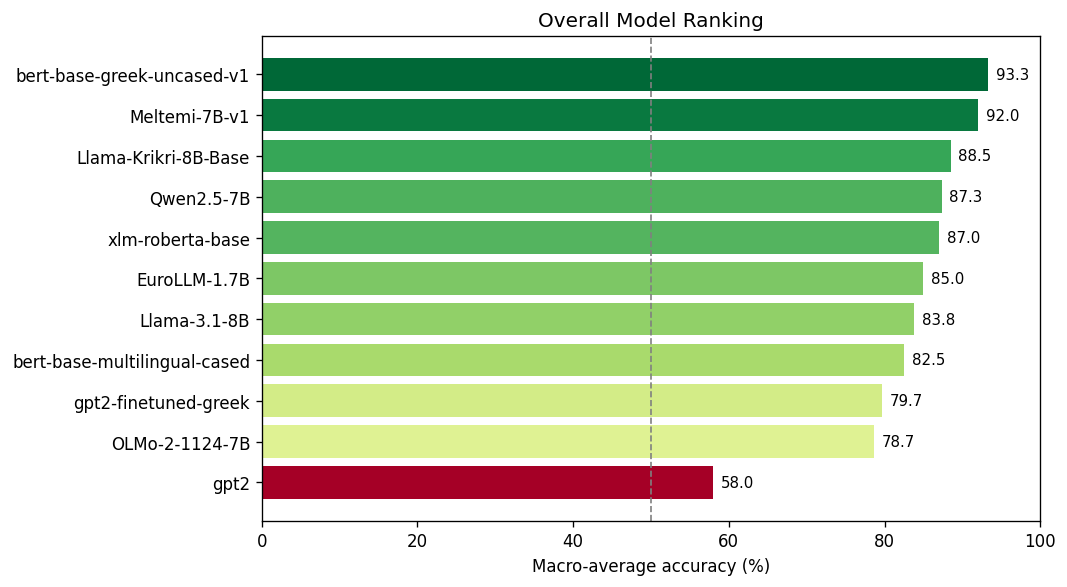

Model
bert-base-greek-uncased-v1      93.3
Meltemi-7B-v1                   92.0
Llama-Krikri-8B-Base            88.5
Qwen2.5-7B                      87.3
xlm-roberta-base                87.0
EuroLLM-1.7B                    85.0
Llama-3.1-8B                    83.8
bert-base-multilingual-cased    82.5
gpt2-finetuned-greek            79.7
OLMo-2-1124-7B                  78.7
gpt2                            58.0
dtype: float64


In [7]:
model_ranking = pivot.drop(index='Macro Average').drop(columns=['Avg', 'SD']).mean(axis=0).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, max(5, 0.4 * len(model_ranking))))
colors = plt.cm.RdYlGn((model_ranking.values - model_ranking.min()) / (model_ranking.max() - model_ranking.min() + 1e-9))
ax.barh(model_ranking.index[::-1], model_ranking.values[::-1], color=colors[::-1])
ax.axvline(50, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Macro-average accuracy (%)')
ax.set_title('Overall Model Ranking')
ax.set_xlim(0, 100)
for i, v in enumerate(model_ranking.values[::-1]):
    ax.text(v + 1, i, f"{v:.1f}", va='center', fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "model_ranking.png", dpi=200, bbox_inches='tight')
plt.show()

print(model_ranking.round(1))

## 2. Accuracy by Phenomenon

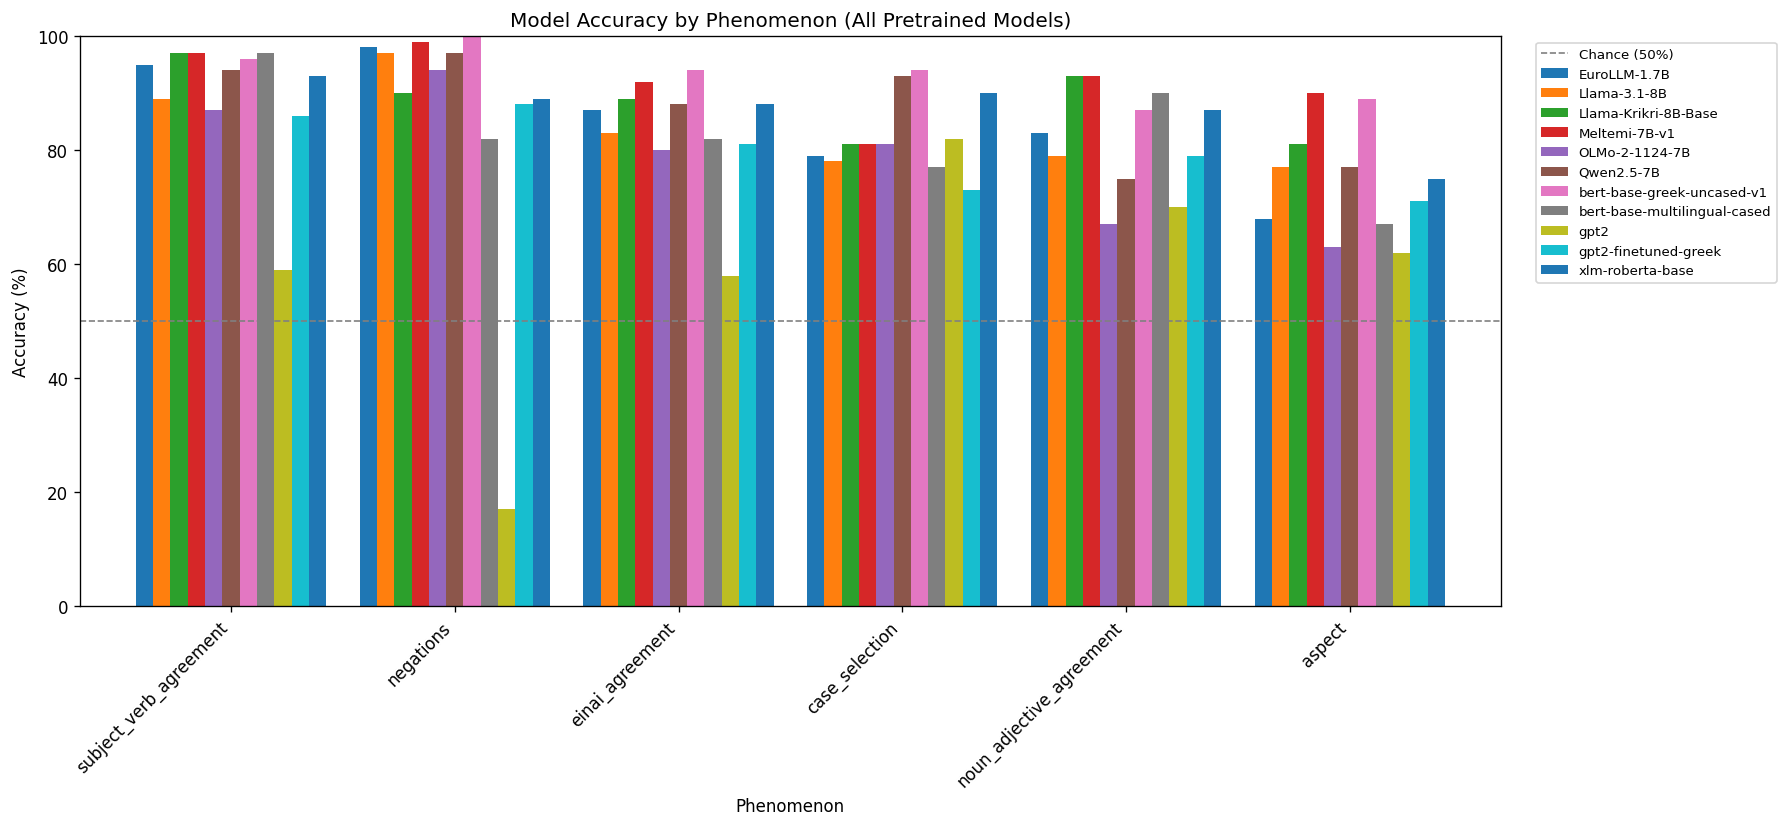

In [8]:
plot_data = pivot.drop(index='Macro Average').drop(columns=['Avg', 'SD'])

fig, ax = plt.subplots(figsize=(15, 7))
plot_data.plot(kind='bar', ax=ax, width=0.85)
ax.axhline(50, color='gray', linestyle='--', linewidth=1, label='Chance (50%)')
ax.set_ylabel('Accuracy (%)')
ax.set_xlabel('Phenomenon')
ax.set_title('Model Accuracy by Phenomenon (All Pretrained Models)')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax.set_ylim(0, 100)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "accuracy_by_phenomenon_bars.png", dpi=200, bbox_inches='tight')
plt.show()

## 3. Confidence Analysis (ΔNLL)\n\nΔNLL = surprisal(ungrammatical) − surprisal(grammatical). Positive means the model favored the grammatical sentence.

In [9]:
delta_rows = []
for model_name, d in all_model_results.items():
    for phen, r in d['per_phenomenon'].items():
        for pair in r.get('pairs', []):
            gram_s = pair.get('gram_surprisal')
            ungram_s = pair.get('ungram_surprisal')
            if gram_s is not None and ungram_s is not None:
                delta_rows.append({'Model': short_name(model_name), 'Phenomenon': phen, 'delta_nll': ungram_s - gram_s})

delta_df = pd.DataFrame(delta_rows)
print(f"Loaded {len(delta_df):,} pair-level confidence values")

Loaded 6,600 pair-level confidence values


/tmp/ipykernel_435/2466977965.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_data, vert=False, labels=phen_order, showfliers=True)


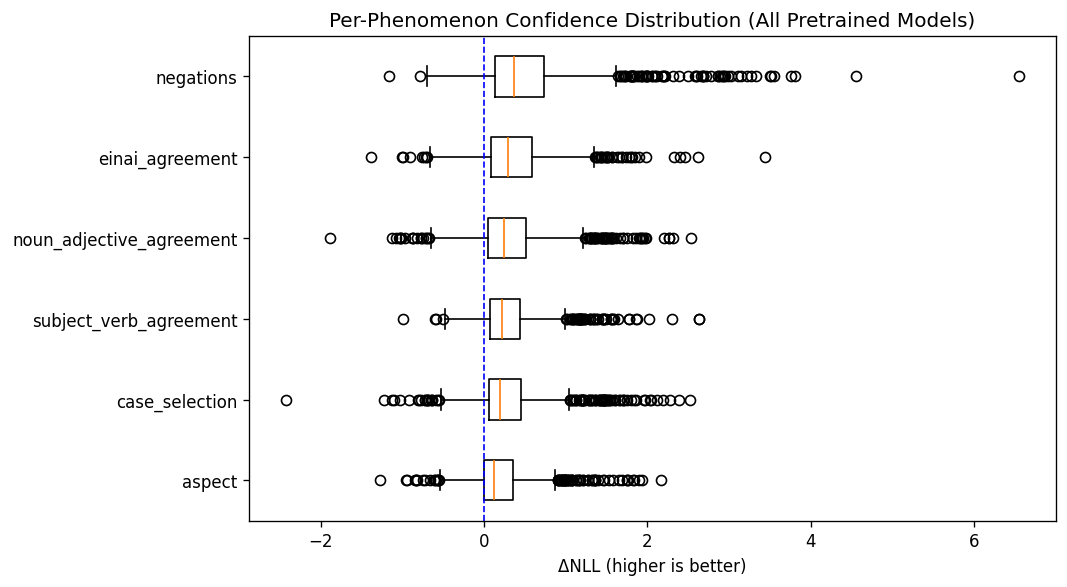

In [10]:
if not delta_df.empty:
    phen_order = delta_df.groupby('Phenomenon')['delta_nll'].mean().sort_values().index

    fig, ax = plt.subplots(figsize=(9, max(5, 0.35 * len(phen_order))))
    box_data = [delta_df[delta_df['Phenomenon'] == p]['delta_nll'].values for p in phen_order]
    ax.boxplot(box_data, vert=False, labels=phen_order, showfliers=True)
    ax.axvline(0, color='blue', linestyle='--', linewidth=1)
    ax.set_xlabel('ΔNLL (higher is better)')
    ax.set_title('Per-Phenomenon Confidence Distribution (All Pretrained Models)')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "delta_nll_boxplot.png", dpi=200, bbox_inches='tight')
    plt.show()

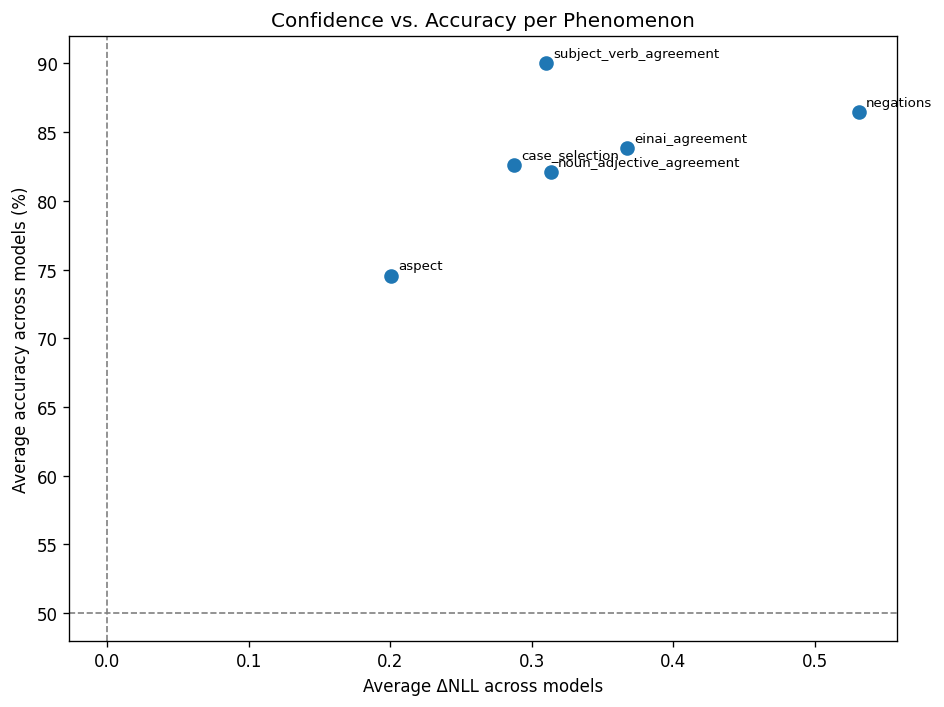

In [11]:
if not delta_df.empty:
    avg_delta = delta_df.groupby('Phenomenon')['delta_nll'].mean()
    avg_acc = pivot.drop(index='Macro Average')['Avg'] / 100

    merged = pd.DataFrame({'avg_delta_nll': avg_delta, 'avg_accuracy': avg_acc}).dropna()

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(merged['avg_delta_nll'], merged['avg_accuracy'] * 100, s=60)
    for phen, row in merged.iterrows():
        ax.annotate(phen, (row['avg_delta_nll'], row['avg_accuracy'] * 100),
                    fontsize=8, xytext=(4, 4), textcoords='offset points')
    ax.axvline(0, color='gray', linestyle='--', linewidth=1)
    ax.axhline(50, color='gray', linestyle='--', linewidth=1)
    ax.set_xlabel('Average ΔNLL across models')
    ax.set_ylabel('Average accuracy across models (%)')
    ax.set_title('Confidence vs. Accuracy per Phenomenon')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "confidence_vs_accuracy.png", dpi=200, bbox_inches='tight')
    plt.show()

## 4. Sample-Size Stability + MPAD

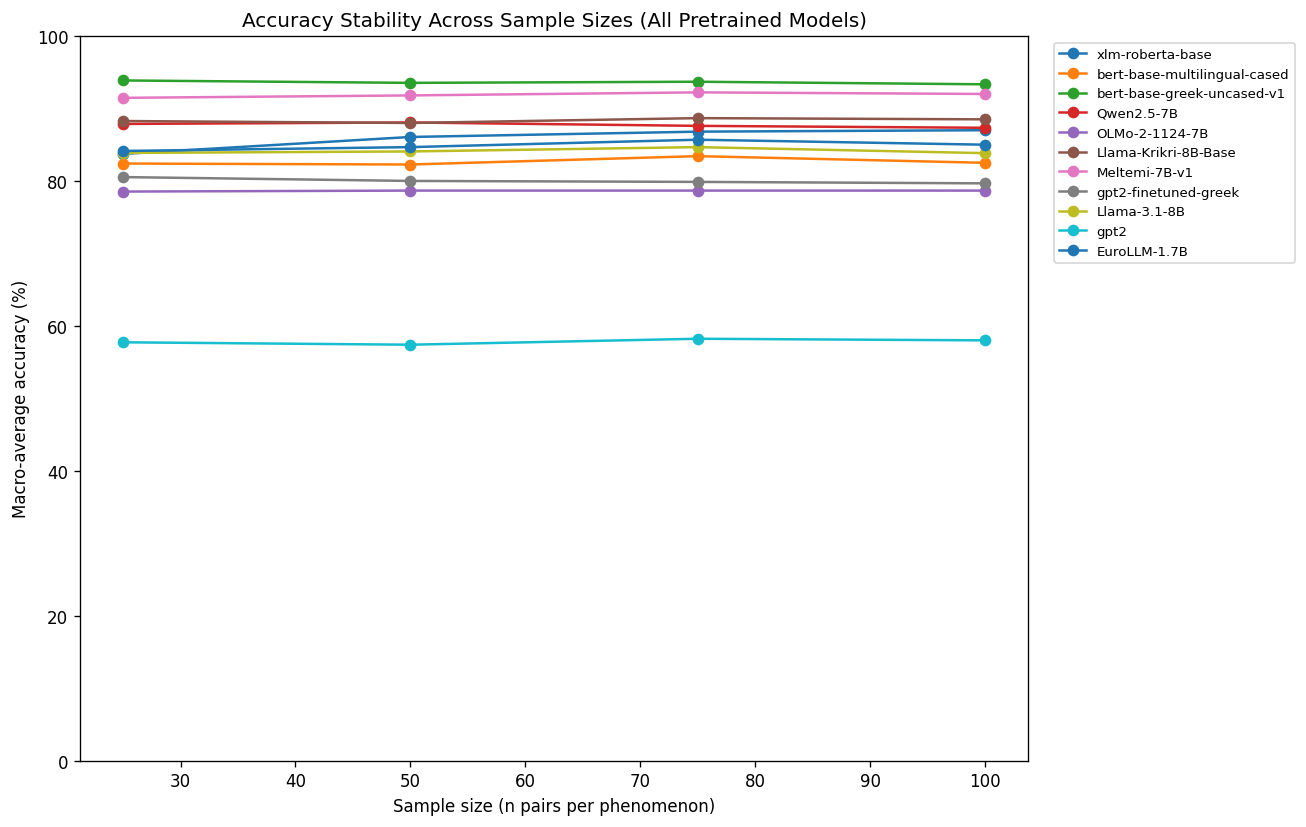

In [12]:
fig, ax = plt.subplots(figsize=(11, 7))

for model_name, d in all_model_results.items():
    stability = d.get('stability', {})
    if not stability:
        continue
    sizes = sorted({int(s) for phen_stab in stability.values() for s in phen_stab.keys()})
    macro_accs = []
    for size in sizes:
        vals = [phen_stab[str(size)]['mean_accuracy']
                for phen_stab in stability.values() if str(size) in phen_stab]
        macro_accs.append(np.mean(vals) * 100 if vals else np.nan)
    ax.plot(sizes, macro_accs, marker='o', label=short_name(model_name), linewidth=1.5)

ax.set_xlabel('Sample size (n pairs per phenomenon)')
ax.set_ylabel('Macro-average accuracy (%)')
ax.set_title('Accuracy Stability Across Sample Sizes (All Pretrained Models)')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "sample_size_stability.png", dpi=200, bbox_inches='tight')
plt.show()

In [13]:
mpad_rows = []
for model_name, d in all_model_results.items():
    stability = d.get('stability', {})
    if not stability:
        continue
    sizes = sorted({int(s) for phen_stab in stability.values() for s in phen_stab.keys()})
    size_macro_acc = {}
    for size in sizes:
        vals = [phen_stab[str(size)]['mean_accuracy']
                for phen_stab in stability.values() if str(size) in phen_stab]
        if vals:
            size_macro_acc[size] = np.mean(vals)

    diffs = [abs(size_macro_acc[a] - size_macro_acc[b]) for a, b in combinations(size_macro_acc.keys(), 2)]
    if diffs:
        mpad_rows.append({'Model': short_name(model_name), 'MPAD (pp)': np.mean(diffs) * 100})

mpad_df = pd.DataFrame(mpad_rows).sort_values('MPAD (pp)')
print(mpad_df.round(2).to_string(index=False))
print(f"\nCross-model mean MPAD: {mpad_df['MPAD (pp)'].mean():.2f} percentage points")
mpad_df.to_csv(OUTPUT_DIR / "mpad_stability.csv", index=False)

                       Model  MPAD (pp)
              OLMo-2-1124-7B       0.07
  bert-base-greek-uncased-v1       0.29
        Llama-Krikri-8B-Base       0.37
                  Qwen2.5-7B       0.41
               Meltemi-7B-v1       0.41
                Llama-3.1-8B       0.45
                        gpt2       0.46
        gpt2-finetuned-greek       0.46
bert-base-multilingual-cased       0.59
                EuroLLM-1.7B       0.83
            xlm-roberta-base       1.76

Cross-model mean MPAD: 0.55 percentage points


## 5. Learning Curve (Small Llama)\n\nAccuracy vs. percentage of Wikipedia training data used, for the custom-trained Small Llama model at 5 checkpoints.

In [14]:
small_llama_results = {}
for fraction_name, fraction_dir in SMALL_LLAMA_FRACTIONS.items():
    if fraction_dir.exists():
        try:
            small_llama_results[fraction_name] = load_small_llama_fraction(fraction_dir)
            print(f"Loaded {fraction_name}: overall accuracy = {small_llama_results[fraction_name]['overall_accuracy']:.2%}")
        except FileNotFoundError as e:
            print(f"Skipped {fraction_name}: {e}")
    else:
        print(f"Skipped {fraction_name}: folder not found")

Loaded 20%: overall accuracy = 75.83%
Loaded 40%: overall accuracy = 75.83%
Loaded 60%: overall accuracy = 81.00%
Loaded 80%: overall accuracy = 79.00%
Loaded 100%: overall accuracy = 80.50%


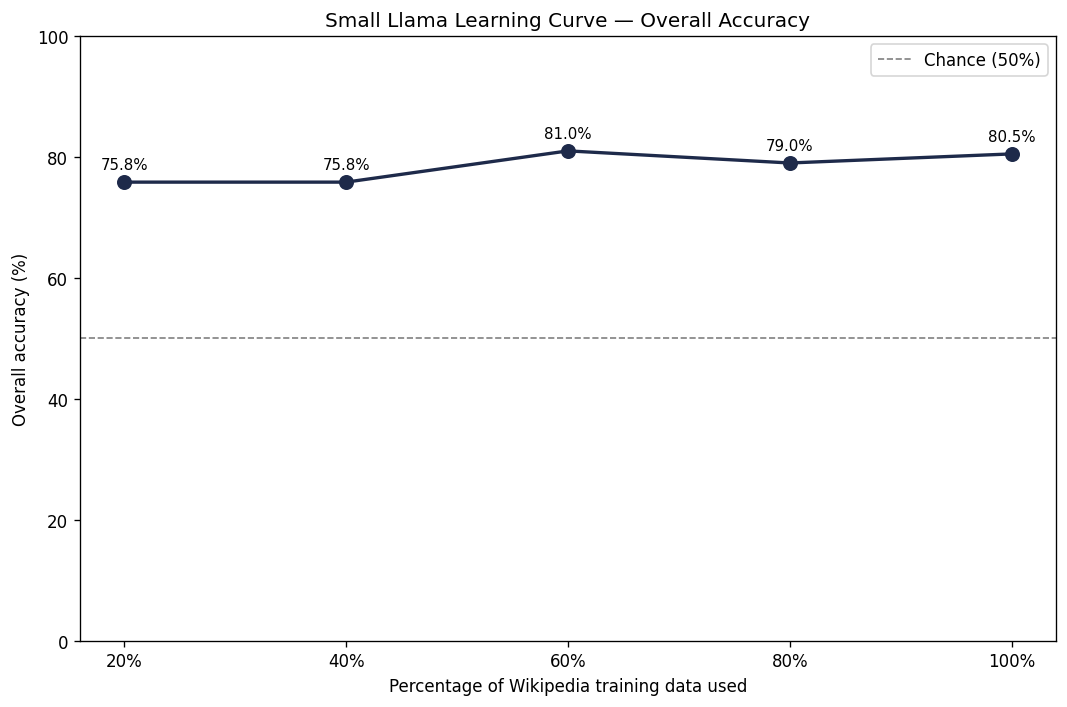

In [15]:
fraction_order = ["20%", "40%", "60%", "80%", "100%"]
fraction_values = [20, 40, 60, 80, 100]

available_fractions = [f for f in fraction_order if f in small_llama_results]
available_values = [fraction_values[fraction_order.index(f)] for f in available_fractions]

overall_accs = [small_llama_results[f]['overall_accuracy'] * 100 for f in available_fractions]

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(available_values, overall_accs, marker='o', linewidth=2, markersize=8, color='#1E2A4A')
ax.axhline(50, color='gray', linestyle='--', linewidth=1, label='Chance (50%)')
ax.set_xlabel('Percentage of Wikipedia training data used')
ax.set_ylabel('Overall accuracy (%)')
ax.set_title('Small Llama Learning Curve — Overall Accuracy')
ax.set_xticks(available_values)
ax.set_xticklabels([f"{v}%" for v in available_values])
ax.set_ylim(0, 100)
ax.legend()
for x, y in zip(available_values, overall_accs):
    ax.annotate(f"{y:.1f}%", (x, y), textcoords="offset points", xytext=(0, 8), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "learning_curve_overall.png", dpi=200, bbox_inches='tight')
plt.show()

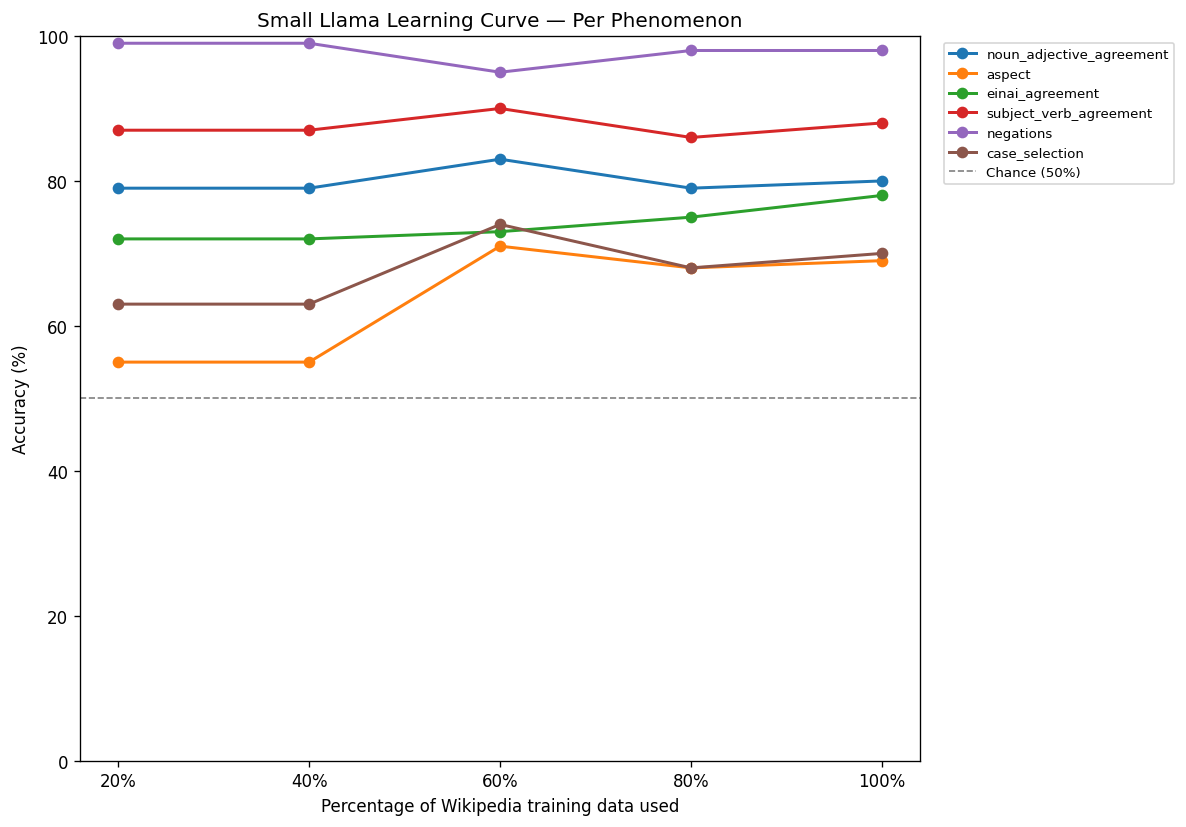

In [16]:
# Per-phenomenon learning curves
phenomena_list = list(small_llama_results[available_fractions[0]]['per_phenomenon'].keys())

fig, ax = plt.subplots(figsize=(10, 7))
for phen in phenomena_list:
    accs = [small_llama_results[f]['per_phenomenon'][phen]['accuracy'] * 100 for f in available_fractions]
    ax.plot(available_values, accs, marker='o', label=phen, linewidth=1.8)

ax.axhline(50, color='gray', linestyle='--', linewidth=1, label='Chance (50%)')
ax.set_xlabel('Percentage of Wikipedia training data used')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Small Llama Learning Curve — Per Phenomenon')
ax.set_xticks(available_values)
ax.set_xticklabels([f"{v}%" for v in available_values])
ax.set_ylim(0, 100)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "learning_curve_per_phenomenon.png", dpi=200, bbox_inches='tight')
plt.show()

In [17]:
# Learning curve summary table
learning_rows = []
for f in available_fractions:
    row = {'Data Fraction': f, 'Overall': small_llama_results[f]['overall_accuracy'] * 100}
    for phen in phenomena_list:
        row[phen] = small_llama_results[f]['per_phenomenon'][phen]['accuracy'] * 100
    learning_rows.append(row)

learning_df = pd.DataFrame(learning_rows).set_index('Data Fraction').round(1)
print(learning_df.to_string())
learning_df.to_csv(OUTPUT_DIR / "learning_curve_table.csv")
print(f"\nSaved to {OUTPUT_DIR / 'learning_curve_table.csv'}")

               Overall  noun_adjective_agreement  aspect  einai_agreement  subject_verb_agreement  negations  case_selection
Data Fraction                                                                                                               
20%               75.8                      79.0    55.0             72.0                    87.0       99.0            63.0
40%               75.8                      79.0    55.0             72.0                    87.0       99.0            63.0
60%               81.0                      83.0    71.0             73.0                    90.0       95.0            74.0
80%               79.0                      79.0    68.0             75.0                    86.0       98.0            68.0
100%              80.5                      80.0    69.0             78.0                    88.0       98.0            70.0

Saved to /content/drive/MyDrive/Thesis/results/analysis_full/learning_curve_table.csv


## 6. Prompting vs. Log-Probability Comparison

In [18]:
prompting_rows = []
if PROMPTING_DIR.exists():
    for f in sorted(PROMPTING_DIR.glob("*_prompting_comparison.json")):
        with open(f, encoding='utf-8') as fh:
            data = json.load(fh)
        prompting_rows.append({
            'Model': short_name(data['model']),
            'Backend': data['backend'],
            'Prompting Acc. (%)': data['prompting_accuracy'] * 100 if data['prompting_accuracy'] is not None else None,
            'Log-prob Acc. (%)': data['logprob_accuracy'] * 100 if data['logprob_accuracy'] is not None else None,
            'Agreement (%)': data['method_agreement'] * 100 if data['method_agreement'] is not None else None,
        })

# Also include GPT-5.4-nano's standalone full evaluation, if it only has
# a _results.json (prompting-only, no comparison file)
gpt54nano_results = PROMPTING_DIR / "gpt-5_4-nano-2026-03-17_results.json"
if gpt54nano_results.exists() and not any(r['Model'] == 'gpt-5.4-nano-2026-03-17' for r in prompting_rows):
    with open(gpt54nano_results, encoding='utf-8') as f:
        data = json.load(f)
    prompting_rows.append({
        'Model': short_name(data['model']),
        'Backend': 'openai',
        'Prompting Acc. (%)': data['overall']['accuracy'] * 100,
        'Log-prob Acc. (%)': None,
        'Agreement (%)': None,
    })

prompting_df = pd.DataFrame(prompting_rows)
print(prompting_df.round(1).to_string(index=False))
prompting_df.to_csv(OUTPUT_DIR / "prompting_vs_logprob.csv", index=False)

                  Model Backend  Prompting Acc. (%)  Log-prob Acc. (%)  Agreement (%)
             Qwen2.5-7B   local                75.3               88.0           67.3
         OLMo-2-1124-7B   local                49.3               76.0           44.0
gpt-5.4-nano-2026-03-17  openai                93.3                NaN            NaN
   Llama-Krikri-8B-Base   local                40.7               86.7           38.0
          Meltemi-7B-v1   local                49.3               90.7           49.3
   gpt2-finetuned-greek   local                 2.0               79.3           22.7
           Llama-3.1-8B   local                70.0               81.3           63.3
                   gpt2   local                 0.0               59.3           40.7
           EuroLLM-1.7B   local                48.7               82.0           44.0


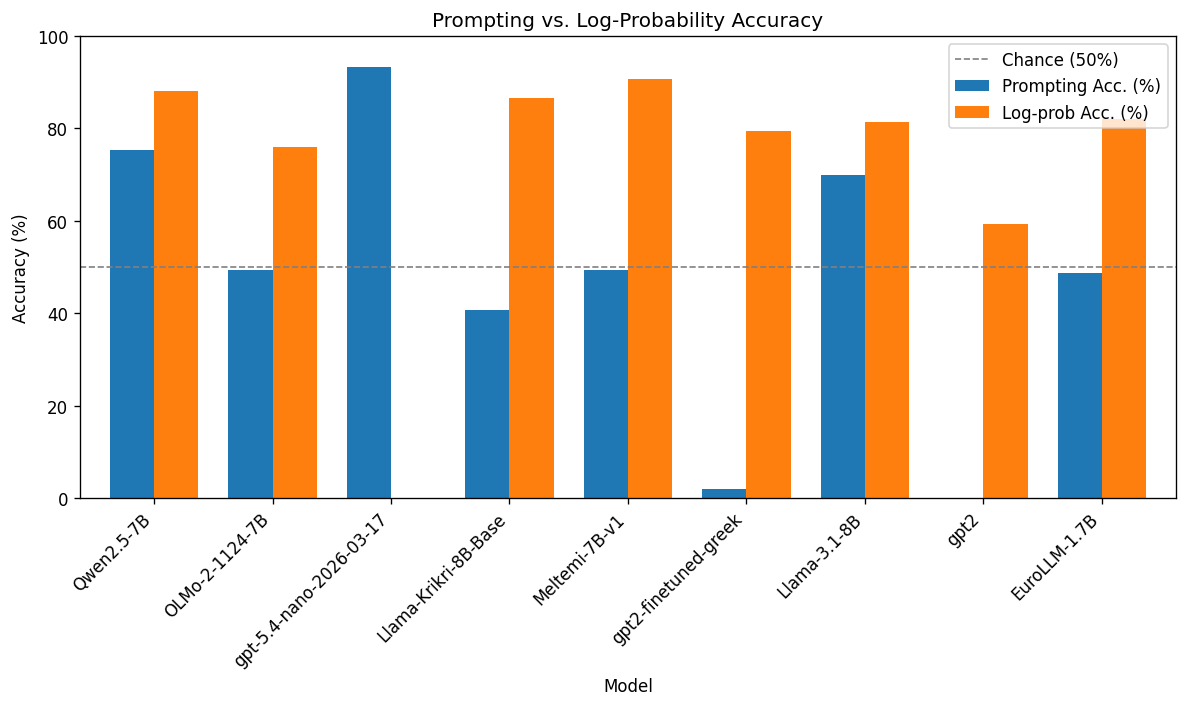

In [19]:
if not prompting_df.empty:
    plot_df = prompting_df.set_index('Model')[['Prompting Acc. (%)', 'Log-prob Acc. (%)']].dropna(how='all')

    fig, ax = plt.subplots(figsize=(10, 6))
    plot_df.plot(kind='bar', ax=ax, width=0.75)
    ax.axhline(50, color='gray', linestyle='--', linewidth=1, label='Chance (50%)')
    ax.set_ylabel('Accuracy (%)')
    ax.set_title('Prompting vs. Log-Probability Accuracy')
    ax.set_ylim(0, 100)
    ax.legend()
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "prompting_vs_logprob_bars.png", dpi=200, bbox_inches='tight')
    plt.show()

## Summary

In [20]:
print("ANALYSIS COMPLETE\n")
print(f"Pretrained models analyzed: {len(all_model_results)}")
print(f"Small Llama fractions analyzed: {len(small_llama_results)}")
print(f"Prompting comparisons analyzed: {len(prompting_rows)}")
print(f"\nAll outputs saved to: {OUTPUT_DIR}")
for f in sorted(OUTPUT_DIR.glob('*')):
    print(f"  {f.name}")

ANALYSIS COMPLETE

Pretrained models analyzed: 11
Small Llama fractions analyzed: 5
Prompting comparisons analyzed: 9

All outputs saved to: /content/drive/MyDrive/Thesis/results/analysis_full
  accuracy_by_phenomenon_bars.png
  confidence_vs_accuracy.png
  delta_nll_boxplot.png
  learning_curve_overall.png
  learning_curve_per_phenomenon.png
  learning_curve_table.csv
  model_ranking.png
  mpad_stability.csv
  prompting_vs_logprob.csv
  prompting_vs_logprob_bars.png
  sample_size_stability.png
  table_accuracy_by_phenomenon_model.csv


In [22]:
avg_delta_by_phenomenon = delta_df.groupby('Phenomenon')['delta_nll'].mean().sort_values(ascending=False)
print(avg_delta_by_phenomenon.round(3))

avg_delta_by_phenomenon.to_csv(OUTPUT_DIR / "avg_delta_nll_by_phenomenon.csv")
print(f"\nSaved to {OUTPUT_DIR / 'avg_delta_nll_by_phenomenon.csv'}")



avg_acc_by_phenomenon = pivot.drop(index='Macro Average')['Avg'].sort_values(ascending=False)
print(avg_acc_by_phenomenon.round(2))
avg_acc_by_phenomenon.to_csv(OUTPUT_DIR / "avg_accuracy_by_phenomenon.csv")

Phenomenon
negations                   0.531
einai_agreement             0.367
noun_adjective_agreement    0.314
subject_verb_agreement      0.310
case_selection              0.288
aspect                      0.201
Name: delta_nll, dtype: float64

Saved to /content/drive/MyDrive/Thesis/results/analysis_full/avg_delta_nll_by_phenomenon.csv
Phenomenon
subject_verb_agreement      90.00
negations                   86.45
einai_agreement             83.82
case_selection              82.64
noun_adjective_agreement    82.09
aspect                      74.55
Name: Avg, dtype: float64


In [23]:
print(mpad_df.round(2).to_string(index=False))
print(f"\nCross-model mean MPAD: {mpad_df['MPAD (pp)'].mean():.2f} percentage points")

                       Model  MPAD (pp)
              OLMo-2-1124-7B       0.07
  bert-base-greek-uncased-v1       0.29
        Llama-Krikri-8B-Base       0.37
                  Qwen2.5-7B       0.41
               Meltemi-7B-v1       0.41
                Llama-3.1-8B       0.45
                        gpt2       0.46
        gpt2-finetuned-greek       0.46
bert-base-multilingual-cased       0.59
                EuroLLM-1.7B       0.83
            xlm-roberta-base       1.76

Cross-model mean MPAD: 0.55 percentage points
